<a href="https://colab.research.google.com/github/nemoiitkgp/FWI-Codes-PhD/blob/main/PP_Benchmark_FWI_Models_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install deepwave scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 MB 8.8 MB/s eta 0:00:00


Device: cuda
Starting FWI Inversion...
Epoch 20 | Loss: 22.941296
Epoch 40 | Loss: 14.697848
Epoch 60 | Loss: 9.096725
Epoch 80 | Loss: 5.823413
Epoch 100 | Loss: 3.686342
Epoch 120 | Loss: 1.911707
Epoch 140 | Loss: 0.784922
Epoch 160 | Loss: 0.344333
Epoch 180 | Loss: 0.172650
Epoch 200 | Loss: 0.099703
Epoch 220 | Loss: 0.064167
Epoch 240 | Loss: 0.044816
Epoch 260 | Loss: 0.033300
Epoch 280 | Loss: 0.025947
Epoch 300 | Loss: 0.020967
Epoch 320 | Loss: 0.017424
Epoch 340 | Loss: 0.014798
Epoch 360 | Loss: 0.012784
Epoch 380 | Loss: 0.011198
Epoch 400 | Loss: 0.009921
Epoch 420 | Loss: 0.008876
Epoch 440 | Loss: 0.008007
Epoch 460 | Loss: 0.022863
Epoch 480 | Loss: 0.007432
Epoch 500 | Loss: 0.006130
Epoch 520 | Loss: 0.005680
Epoch 540 | Loss: 0.005267
Epoch 560 | Loss: 0.004914
Epoch 580 | Loss: 0.004599
Epoch 600 | Loss: 0.004318
Epoch 620 | Loss: 0.006014
Epoch 640 | Loss: 0.004541
Epoch 660 | Loss: 0.004051
Epoch 680 | Loss: 0.003466
Epoch 700 | Loss: 0.003298
Epoch 720 | Loss: 

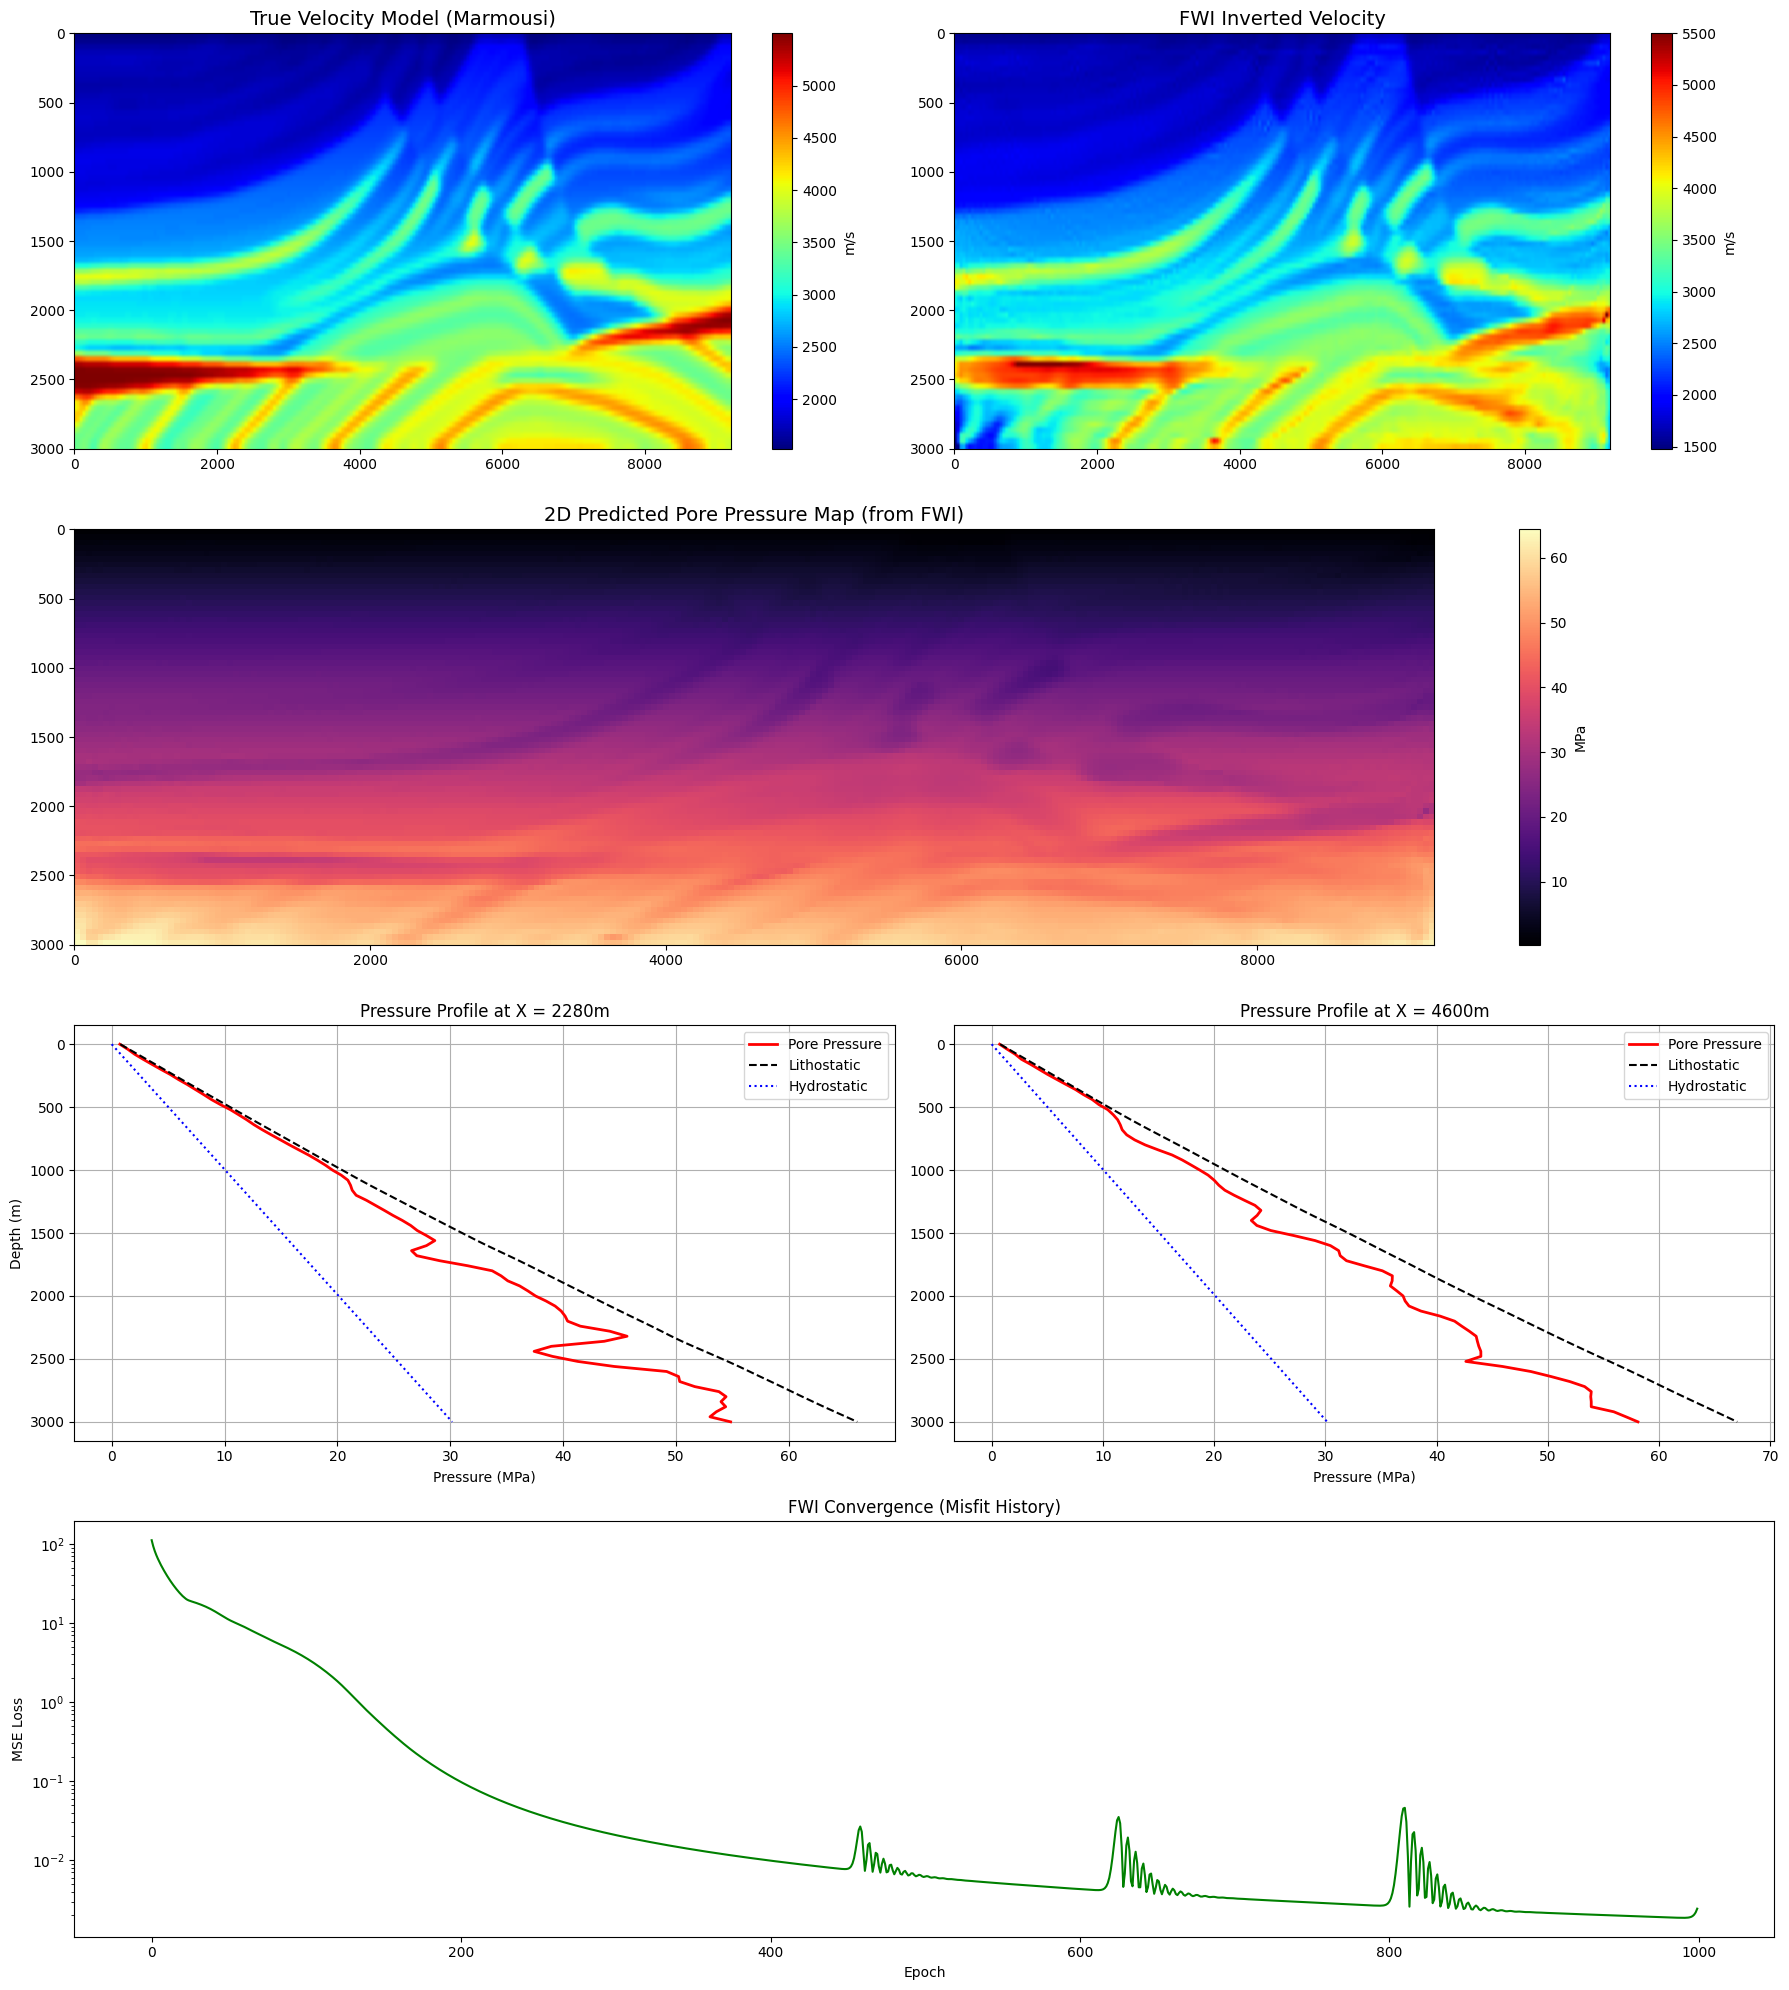

Process Complete. FWI-based Pore Pressure Prediction is visualized.


In [7]:
import os
import torch
import numpy as np
import scipy.io
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import deepwave
from deepwave import scalar

# ---------------------------------------------------------
# 1. SETUP & DATA PREPARATION (From Code 1)
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Load Marmousi (Assuming the .bin file exists as per Code 1)
# If you are running this for the first time, ensure marmousi_vp.bin is in the directory
vp_path = 'marmousi_vp.bin'
nx0, nz0 = 2301, 751 # Original Marmousi size

# For demonstration, if file doesn't exist, we create a dummy or skip
if not os.path.exists(vp_path):
    print(f"File {vp_path} not found. Creating a synthetic Marmousi-style block for demo.")
    vp_dummy = np.full((nx0, nz0), 1500.0, dtype=np.float32)
    vp_dummy[:, 300:] = 3000.0
    vp_dummy.tofile(vp_path)

vp = torch.from_file(vp_path, size=nx0 * nz0, dtype=torch.float32).reshape(nx0, nz0).to(device)

# Subsampling to speed up FWI
factor = 10   # Increased factor slightly for faster execution
vp_np = vp.detach().cpu().numpy()
vp_smooth = gaussian_filter(vp_np, sigma=factor)
vp_reduced = vp_smooth[::factor, ::factor]
nx, nz = vp_reduced.shape

dx = 4.0 * factor
dz = 4.0 * factor
spacing = (dx, dz)
extent = [0, (nx - 1) * dx, (nz - 1) * dz, 0]

v_true = torch.from_numpy(vp_reduced).to(device)
v_init = (torch.tensor(1/gaussian_filter(1/v_true.cpu(), 15)).to(device)) # Initial model
v1 = v_init.clone()

# ---------------------------------------------------------
# 2. ACQUISITION GEOMETRY & FORWARD MODELING
# ---------------------------------------------------------
n_shots = 12
n_sources_per_shot = 1
source_depth = 2
n_receivers_per_shot = 100
receiver_depth = 2

freq = 5.0
nt = 1000
dt = 0.004
peak_time = 1.5/freq

source_loc = torch.zeros(n_shots, 1, 2, dtype=torch.long, device=device)
source_loc[..., 1] = source_depth
source_loc[:, 0, 0] = torch.linspace(0, nx - 1, n_shots).round()

receiver_loc = torch.zeros(n_shots, n_receivers_per_shot, 2, dtype=torch.long, device=device)
receiver_loc[..., 1] = receiver_depth
receiver_loc[:, :, 0] = torch.linspace(0, nx - 1, n_receivers_per_shot).round()

source_amp = deepwave.wavelets.ricker(freq, nt, dt, peak_time).repeat(n_shots, 1, 1).to(device)

# Generate Observed Data
out_obs = scalar(v_true, spacing, dt, source_amplitudes=source_amp,
                 source_locations=source_loc, receiver_locations=receiver_loc,
                 pml_freq=freq)
observed_data = out_obs[-1]
observed_data_tapered = deepwave.common.cosine_taper_end(observed_data, 5)

# ---------------------------------------------------------
# 3. FULL WAVEFORM INVERSION (FWI)
# ---------------------------------------------------------
v1.requires_grad_()
loss_fn = torch.nn.MSELoss()
n_epochs = 1000  # Set to 800 for full production quality
optimizer = torch.optim.Adam([v1], lr=20.0)

print("Starting FWI Inversion...")
losses = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    out_pred = scalar(v1, spacing, dt, source_amplitudes=source_amp,
                      source_locations=source_loc, receiver_locations=receiver_loc,
                      pml_freq=freq)
    pred_data = out_pred[-1]
    loss = loss_fn(deepwave.common.cosine_taper_end(pred_data, 5), observed_data_tapered)
    loss.backward()

    # Gradient Post-processing
    with torch.no_grad():
        grad = v1.grad.detach().cpu().numpy()
        grad_smoothed = gaussian_filter(grad, sigma=1)
        v1.grad.copy_(torch.tensor(grad_smoothed).to(device))

    optimizer.step()
    with torch.no_grad():
        v1.clamp_(min=1480.0, max=5500.0)

    losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1} | Loss: {loss.item():.6f}")

# Final Inverted Velocity for Pressure Analysis
vp_fwi_final = v1.detach().cpu().numpy() # Shape (nx, nz)
vp_true_final = v_true.detach().cpu().numpy()

# ---------------------------------------------------------
# 4. PORE PRESSURE ESTIMATION (From Code 2 Framework)
# ---------------------------------------------------------
print("Calculating Pressure Models...")

# Depth vector in meters
depth_vector = np.linspace(0, (nz-1) * dz, nz)

# 1. Lithostatic Pressure (Sv) using Gardner's Relation
# rho = 310 * Vp^0.25 (Vp in m/s)
rho = 310.0 * (vp_fwi_final ** 0.25)
Sv_Pa = np.zeros_like(vp_fwi_final)
for i in range(nx):
    # Integral of rho * g * dz
    Sv_Pa[i, :] = np.cumsum(rho[i, :] * 9.81 * dz)

# 2. Hydrostatic Pressure (Ph)
# Assuming water density 1025 kg/m^3
Ph_Pa = 1025.0 * 9.81 * depth_vector
Ph_MPa = Ph_Pa * 1e-6

# 3. Pore Pressure (Pp) using Bowers' Method
# Bowers constants usually expect Vp in ft/s
# Convert Vp from m/s to ft/s
v_fts = vp_fwi_final * 3.28084
V0 = 5000.0 # Surface velocity in ft/s (~1524 m/s)
A_bow, B_bow = 25.0, 0.8  # (10.0, 0.75 previously)
# A Adjusted for higher velocity range
# B Adjusted for compaction sensitivity

# Effective Stress (Sigma) from Bowers
v_term = np.maximum(v_fts - V0, 1.0)
sigma_eff_Pa = ((v_term / A_bow)**(1.0/B_bow)) * 6894.76 # Convert psi to Pa

# Pp = Sv - Effective Stress
Pp_Pa = Sv_Pa - sigma_eff_Pa

# Ensure Pore Pressure is at least Hydrostatic
for i in range(nx):
    Pp_Pa[i, :] = np.maximum(Pp_Pa[i, :], Ph_Pa)

Pp_MPa = Pp_Pa * 1e-6
Sv_MPa = Sv_Pa * 1e-6

# ---------------------------------------------------------
# 5. INTEGRATED VISUALIZATION
# ---------------------------------------------------------
fig = plt.figure(figsize=(18, 20))
gs = fig.add_gridspec(4, 2)

# Plot 1: True Velocity
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(vp_true_final.T, extent=extent, cmap='jet', aspect='auto')
ax1.set_title("True Velocity Model (Marmousi)", fontsize=14)
plt.colorbar(im1, ax=ax1, label="m/s")

# Plot 2: FWI Inverted Velocity
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(vp_fwi_final.T, extent=extent, cmap='jet', aspect='auto')
ax2.set_title("FWI Inverted Velocity", fontsize=14)
plt.colorbar(im2, ax=ax2, label="m/s")

# Plot 3: 2D Pore Pressure Map
ax3 = fig.add_subplot(gs[1, :])
im3 = ax3.imshow(Pp_MPa.T, extent=extent, cmap='magma', aspect='auto')
ax3.set_title("2D Predicted Pore Pressure Map (from FWI)", fontsize=14)
plt.colorbar(im3, ax=ax3, label="MPa")

# Plot 4: Pressure Profiles at two locations
# We pick X = 1/4 and X = 1/2 of the model width
loc1, loc2 = nx // 4, nx // 2

# Profile 1
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(Pp_MPa[loc1, :], depth_vector, 'r', lw=2, label='Pore Pressure')
ax4.plot(Sv_MPa[loc1, :], depth_vector, 'k--', label='Lithostatic')
ax4.plot(Ph_MPa, depth_vector, 'b:', label='Hydrostatic')
ax4.invert_yaxis()
ax4.set_title(f"Pressure Profile at X = {int(loc1*dx)}m")
ax4.set_xlabel("Pressure (MPa)")
ax4.set_ylabel("Depth (m)")
ax4.legend()
ax4.grid(True)

# Profile 2
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(Pp_MPa[loc2, :], depth_vector, 'r', lw=2, label='Pore Pressure')
ax5.plot(Sv_MPa[loc2, :], depth_vector, 'k--', label='Lithostatic')
ax5.plot(Ph_MPa, depth_vector, 'b:', label='Hydrostatic')
ax5.invert_yaxis()
ax5.set_title(f"Pressure Profile at X = {int(loc2*dx)}m")
ax5.set_xlabel("Pressure (MPa)")
ax5.legend()
ax5.grid(True)

# Plot 6: FWI Convergence
ax6 = fig.add_subplot(gs[3, :])
ax6.plot(losses, color='green')
ax6.set_yscale('log')
ax6.set_title("FWI Convergence (Misfit History)")
ax6.set_xlabel("Epoch")
ax6.set_ylabel("MSE Loss")

plt.tight_layout()
plt.show()

print("Process Complete. FWI-based Pore Pressure Prediction is visualized.")

Using Device: cuda
Generating observed data in batches...
Starting Inversion for 1500 epochs...
Epoch 50 | Loss: 0.50982
Epoch 100 | Loss: 0.15671
Epoch 150 | Loss: 0.08642
Epoch 200 | Loss: 0.05802
Epoch 250 | Loss: 0.04224
Epoch 300 | Loss: 0.03198
Epoch 350 | Loss: 0.02491
Epoch 400 | Loss: 0.01974
Epoch 450 | Loss: 0.01583
Epoch 500 | Loss: 0.01283
Epoch 550 | Loss: 0.01055
Epoch 600 | Loss: 0.00883
Epoch 650 | Loss: 0.00751
Epoch 700 | Loss: 0.00649
Epoch 750 | Loss: 0.00569
Epoch 800 | Loss: 0.00505
Epoch 850 | Loss: 0.00454
Epoch 900 | Loss: 0.00411
Epoch 950 | Loss: 0.00376
Epoch 1000 | Loss: 0.00346
Epoch 1050 | Loss: 0.00321
Epoch 1100 | Loss: 0.00298
Epoch 1150 | Loss: 0.00279
Epoch 1200 | Loss: 0.00261
Epoch 1250 | Loss: 0.00246
Epoch 1300 | Loss: 0.00232
Epoch 1350 | Loss: 0.00219
Epoch 1400 | Loss: 0.00208
Epoch 1450 | Loss: 0.00198
Epoch 1500 | Loss: 0.00189
Computing Pore Pressure (Bowers Method)...


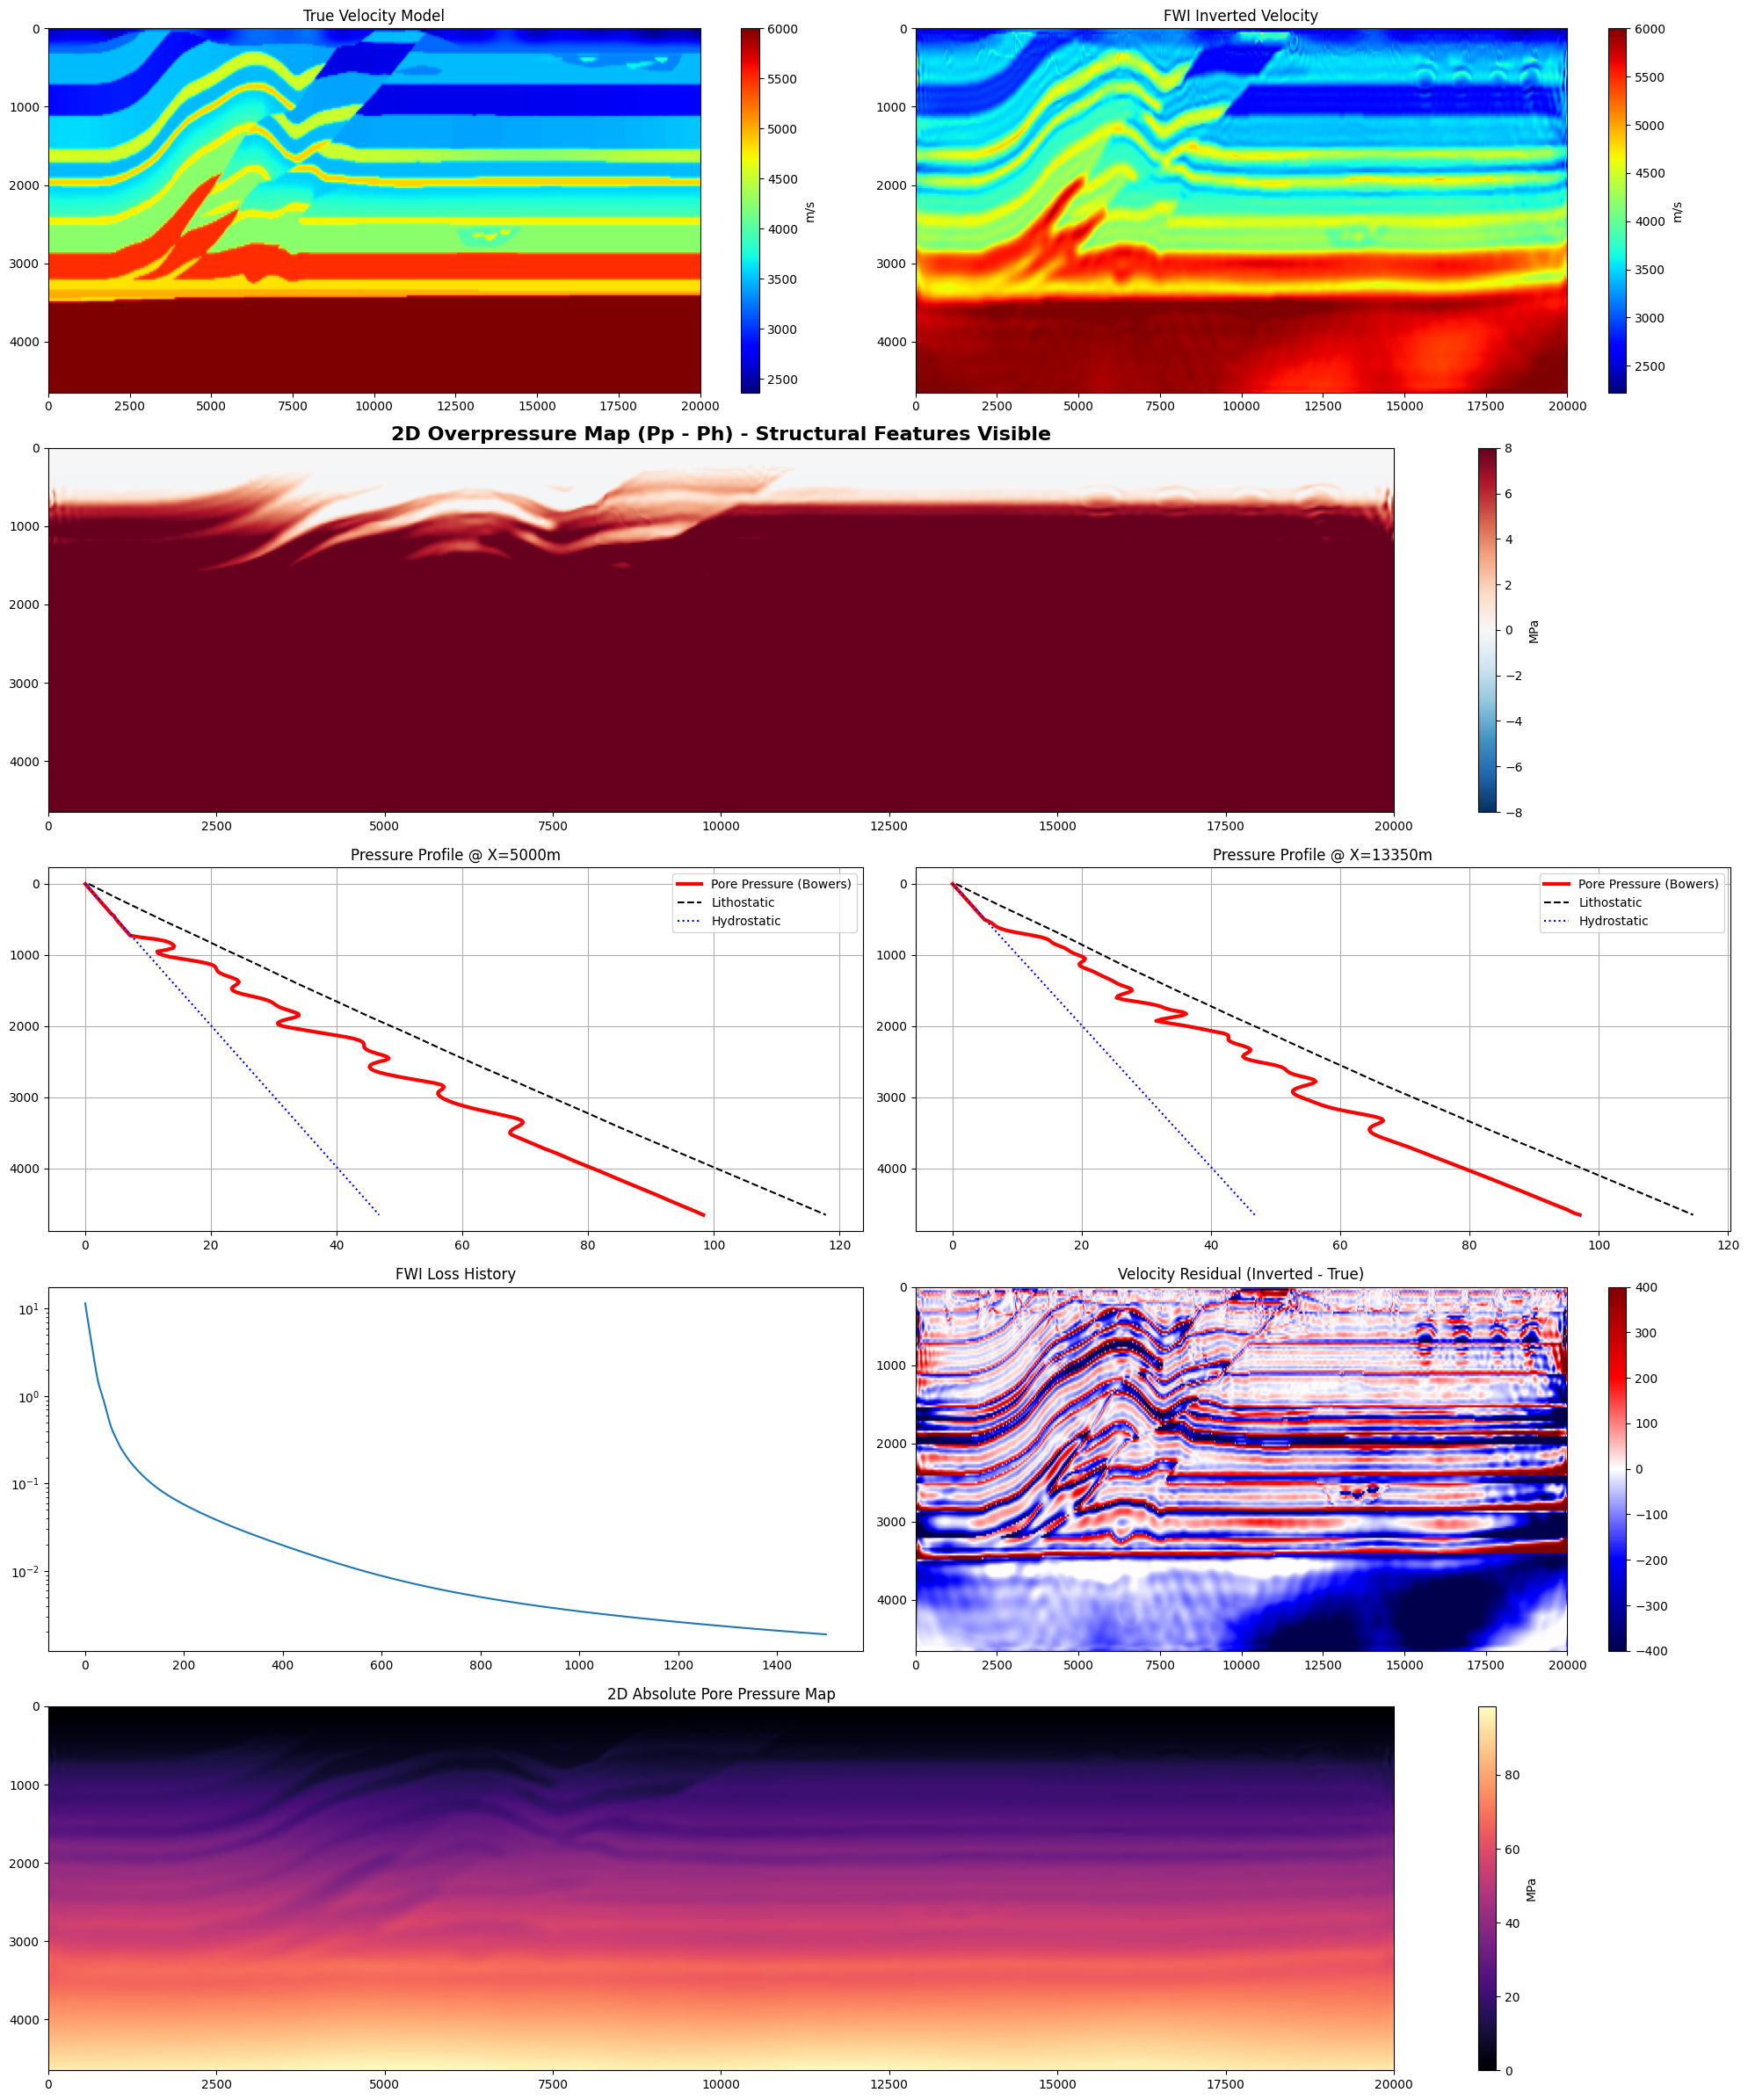

In [5]:
import os
import numpy as np
import torch
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import deepwave
from deepwave import scalar

# ---------------------------------------------------------
# 1. SETUP & DEVICE CONFIGURATION
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

# Model Dimensions (Overthrust)
nx, nz = 801, 187
dx, dz = 25.0, 25.0
spacing = (dx, dz)
extent = [0, (nx - 1) * dx, (nz - 1) * dz, 0]

# Load or Create Overthrust Vp
vp_path = 'overthrust2D'
if not os.path.exists(vp_path):
    print("Creating synthetic Overthrust-style model...")
    # This creates a dummy layered model if the file is missing
    v_dummy = np.full((nx, nz), 2500.0, dtype=np.float32)
    for j in range(nz):
        v_dummy[:, j] += j * 15.0
    v_dummy.tofile(vp_path)

v_true = torch.from_file(vp_path, size=nx * nz, dtype=torch.float32).reshape(nx, nz).to(device)

# 2. INITIAL VELOCITY MODEL
v_init = (torch.tensor(1/gaussian_filter(1/v_true.cpu().numpy(), sigma=15)).to(device))
v1 = v_init.clone()
v1.requires_grad_()

# ---------------------------------------------------------
# 3. ACQUISITION GEOMETRY
# ---------------------------------------------------------
n_shots = 20
n_sources_per_shot = 1
n_receivers_per_shot = 160
freq = 5.0
dt = 0.002
nt = 1500
peak_time = 1.5/freq

source_loc = torch.zeros(n_shots, 1, 2, dtype=torch.long, device=device)
source_loc[..., 1] = 2
source_loc[:, 0, 0] = torch.linspace(0, nx - 1, n_shots).round()

receiver_loc = torch.zeros(n_shots, n_receivers_per_shot, 2, dtype=torch.long, device=device)
receiver_loc[..., 1] = 2
receiver_loc[:, :, 0] = torch.linspace(0, nx - 1, n_receivers_per_shot).round()

source_amp = (deepwave.wavelets.ricker(freq, nt, dt, peak_time)
              .repeat(n_shots, 1, 1).to(device))

# ---------------------------------------------------------
# 4. FORWARD MODELLING (Observed Data)
# ---------------------------------------------------------
print("Generating observed data in batches...")
observed_data = torch.zeros(n_shots, n_receivers_per_shot, nt, device=device)
batch_size = 2

with torch.no_grad():
    for i in range(0, n_shots, batch_size):
        out = scalar(v_true, spacing, dt,
                     source_amplitudes=source_amp[i:i+batch_size],
                     source_locations=source_loc[i:i+batch_size],
                     receiver_locations=receiver_loc[i:i+batch_size],
                     pml_freq=freq)
        observed_data[i:i+batch_size] = out[-1]

def taper(x): return deepwave.common.cosine_taper_end(x, 10)
observed_data_tapered = taper(observed_data)

# ---------------------------------------------------------
# 5. FWI INVERSION LOOP
# ---------------------------------------------------------
loss_fn = torch.nn.MSELoss()
optimiser = torch.optim.Adam([v1], lr=15.0)
n_epochs = 1500 # Set to 1500 for high resolution
losses = []

print(f"Starting Inversion for {n_epochs} epochs...")
for epoch in range(n_epochs):
    optimiser.zero_grad()
    epoch_loss = 0
    for i in range(0, n_shots, batch_size):
        out_pred = scalar(v1, spacing, dt,
                          source_amplitudes=source_amp[i:i+batch_size],
                          source_locations=source_loc[i:i+batch_size],
                          receiver_locations=receiver_loc[i:i+batch_size],
                          pml_freq=freq)
        loss = loss_fn(taper(out_pred[-1]), observed_data_tapered[i:i+batch_size])
        loss = loss / (n_shots / batch_size)
        loss.backward()
        epoch_loss += loss.item()

    with torch.no_grad():
        grad = v1.grad.detach().cpu().numpy()
        v1.grad.copy_(torch.tensor(gaussian_filter(grad, sigma=1.0)).to(device))
        torch.nn.utils.clip_grad_value_([v1], torch.quantile(v1.grad.abs(), 0.98))

    optimiser.step()
    with torch.no_grad(): v1.clamp_(min=2178.0, max=6000.0)
    losses.append(epoch_loss)
    if (epoch + 1) % 50 == 0: print(f"Epoch {epoch+1} | Loss: {epoch_loss:.5f}")

# ---------------------------------------------------------
# 6. CALIBRATED BOWERS PORE PRESSURE ESTIMATION
# ---------------------------------------------------------
print("Computing Pore Pressure (Bowers Method)...")
vp_fwi = v1.detach().cpu().numpy()
depth = np.linspace(0, (nz - 1) * dz, nz)

# 1. Lithostatic Stress (Sv) using Gardner
rho = 310.0 * (vp_fwi ** 0.25)
Sv_Pa = np.zeros_like(vp_fwi)
for i in range(nx):
    Sv_Pa[i, :] = np.cumsum(rho[i, :] * 9.81 * dz)

# 2. Hydrostatic Reference
Ph_Pa = 1025.0 * 9.81 * depth
Ph_MPa = Ph_Pa * 1e-6

# 3. Calibrated Bowers (Adjusted for high Vp models)
v_fts = vp_fwi * 3.28084
V0, A_bow, B_bow = 5000.0, 25.0, 0.8  # CALIBRATED PARAMETERS
sigma_eff_Pa = ((np.maximum(v_fts - V0, 1.0) / A_bow)**(1.0 / B_bow)) * 6894.76

# 4. Resulting Pressures
Pp_Pa = np.maximum(Sv_Pa - sigma_eff_Pa, Ph_Pa * 0.98)
Overpressure_MPa = (Pp_Pa - Ph_Pa.reshape(1, -1)) * 1e-6 # KEY FOR VISUALIZATION
Pp_MPa = Pp_Pa * 1e-6
Sv_MPa = Sv_Pa * 1e-6

# ---------------------------------------------------------
# 7. INTEGRATED VISUALIZATION
# ---------------------------------------------------------
fig = plt.figure(figsize=(20, 24))
gs = fig.add_gridspec(5, 2)

# Velocity
ax1 = fig.add_subplot(gs[0, 0]); im1 = ax1.imshow(v_true.cpu().numpy().T, extent=extent, cmap='jet', aspect='auto')
ax1.set_title("True Velocity Model"); plt.colorbar(im1, ax=ax1, label="m/s")
ax2 = fig.add_subplot(gs[0, 1]); im2 = ax2.imshow(vp_fwi.T, extent=extent, cmap='jet', aspect='auto')
ax2.set_title("FWI Inverted Velocity"); plt.colorbar(im2, ax=ax2, label="m/s")

# Overpressure Map (The Fix)
ax3 = fig.add_subplot(gs[1, :])
im3 = ax3.imshow(Overpressure_MPa.T, extent=extent, cmap='RdBu_r', aspect='auto', vmin=-8, vmax=8)
ax3.set_title("2D Overpressure Map (Pp - Ph) - Structural Features Visible", fontsize=16, fontweight='bold')
plt.colorbar(im3, ax=ax3, label="MPa")

# Pressure Profiles
loc1, loc2 = nx // 4, 2 * nx // 3
for i, loc in enumerate([loc1, loc2]):
    ax = fig.add_subplot(gs[2, i])
    ax.plot(Pp_MPa[loc, :], depth, 'r', lw=3, label='Pore Pressure (Bowers)')
    ax.plot(Sv_MPa[loc, :], depth, 'k--', label='Lithostatic')
    ax.plot(Ph_MPa, depth, 'b:', label='Hydrostatic')
    ax.invert_yaxis(); ax.set_title(f"Pressure Profile @ X={int(loc*dx)}m"); ax.legend(); ax.grid(True)

# Convergence & Residual
ax4 = fig.add_subplot(gs[3, 0]); ax4.plot(losses); ax4.set_yscale('log'); ax4.set_title("FWI Loss History")
ax5 = fig.add_subplot(gs[3, 1]); err = vp_fwi - v_true.cpu().numpy()
im5 = ax5.imshow(err.T, extent=extent, cmap='seismic', aspect='auto', vmin=-400, vmax=400)
ax5.set_title("Velocity Residual (Inverted - True)"); plt.colorbar(im5, ax=ax5)

# Full Pore Pressure Map (Absolute)
ax6 = fig.add_subplot(gs[4, :])
im6 = ax6.imshow(Pp_MPa.T, extent=extent, cmap='magma', aspect='auto')
ax6.set_title("2D Absolute Pore Pressure Map"); plt.colorbar(im6, ax=ax6, label="MPa")

plt.tight_layout(); plt.show()